<a href="https://colab.research.google.com/github/rmilde/econ5200_final_project/blob/main/5200_final_project_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 5200: Consulting Report — Final Project

**From Model to Recommendation**

This notebook scaffolds the full consulting report pipeline: executive summary, identification strategy, causal analysis, threats assessment, Streamlit export, presentation script, and AI methodology appendix.

---

## Part 0: Setup

In [1]:
!pip install doubleml -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.5/603.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.3/230.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.6 MB/s eta 0:00:00


In [2]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.model_selection import cross_val_predict

# Causal ML (uncomment the one you use)
# from econml.dml import LinearDML, CausalForestDML
from doubleml import DoubleMLPLR, DoubleMLData
from doubleml.datasets import fetch_401K

# Stats
from scipy import stats
import statsmodels.api as sm

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


## Part 1: Executive Summary

> **We estimate that 401(k) eligibility increases net financial assets by \$14,441
> (95% CI: [\$11,369, \$17,513]).**
>
> **Situation:** Nearly 40 million American workers lack access to employer-sponsored
> retirement savings plans. Policymakers and firms considering expanding 401(k)
> eligibility need to know whether access causally increases asset accumulation —
> or whether the savings gap between eligible and ineligible workers simply reflects
> pre-existing income differences.
>
> **Complication:** A naive comparison of eligible vs. ineligible workers overstates
> the effect by \$12,931 (naive OLS: \$27,372). Eligible workers earn ~\$16,500 more
> on average and would accumulate more assets regardless of plan access. Prediction
> models explain only 12% of variance in net financial assets (R² = 0.12), confirming
> that observable characteristics alone cannot untangle cause from correlation.
>
> **Resolution:** Using Double Machine Learning on 9,915 observations, we partial out
> income-driven confounding via cross-fitted Gradient Boosting models before estimating
> the causal coefficient. The bias-corrected estimate of \$14,441 is statistically
> significant (p < 0.001) and stable across nuisance model specifications
> (RF robustness check: \$13,838, difference of \$603).
>
> **We recommend that firms and policymakers expand 401(k) eligibility to lower-income
> and part-time workers, because causal evidence shows eligibility increases net
> financial assets by ~\$14,400 independent of income level. At scale, making
> 50,000 workers newly eligible would generate an estimated \$722 million in
> aggregate asset accumulation.**
>
> **Key assumption that could invalidate this:** Conditional independence —
> if unobserved employer characteristics (firm quality, financial planning culture,
> matching contribution rates) simultaneously drive eligibility and savings beyond
> what income captures, the estimate remains upward biased even after DML adjustment.

---
## Part 2: Data + Identification Strategy

### Research Design

- **Research question:** Does 401(k) eligibility cause higher net financial assets?
- **Identification strategy:** Double Machine Learning (DML)
- **Key assumption:** Conditional independence — after controlling for income, age, family size, and education, eligibility is as good as random
- **Treatment variable:** p401 (eligible for 401k = 1)
- **Outcome variable:** net_tfa (net total financial assets)
- **Controls:** inc, age, fsize, educ, pira
- **Why prediction alone is insufficient:** A predictive model tells us who tends to have high savings, but not whether making someone eligible would *cause* them to save more. Confounders like income drive both eligibility and savings.

In [3]:
# --- Data Loading ---
df = fetch_401K(return_type='DataFrame')
print(df.shape)
df.head()

(9915, 14)


,nifa,net_tfa,tw,age,inc,fsize,educ,db,marr,twoearn,e401,p401,pira,hown
0,0.0,0.0,4500.0,47,6765.0,2,8,0,0,0,0,0,0,1
1,6215.0,1015.0,22390.0,36,28452.0,1,16,0,0,0,0,0,0,1
2,0.0,-2000.0,-2000.0,37,3300.0,6,12,1,0,0,0,0,0,0
3,15000.0,15000.0,155000.0,58,52590.0,2,16,0,1,1,0,0,0,1
4,0.0,0.0,58000.0,32,21804.0,1,11,0,0,0,0,0,0,1


In [4]:
# --- EDA: Summary Statistics ---
df.describe()

,nifa,net_tfa,tw,age,inc,fsize,educ,db,marr,twoearn,e401,p401,pira,hown
count,9.915000e+03,9.915000e+03,9.915000e+03,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000,9915.000000
mean,1.392864e+04,1.805153e+04,6.381685e+04,41.060212,37200.621094,2.865860,13.206253,0.271004,0.604841,0.380837,0.371357,0.261624,0.242158,0.635199
std,5.490504e+04,6.352259e+04,1.115296e+05,10.344505,24774.251953,1.538937,2.810382,0.444500,0.488909,0.485617,0.483192,0.439541,0.428411,0.481399
min,0.000000e+00,-5.023020e+05,-5.023020e+05,25.000000,-2652.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000e+02,-5.000000e+02,3.291500e+03,32.000000,19413.000000,2.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.635000e+03,1.499000e+03,2.510000e+04,40.000000,31476.000000,3.000000,12.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,8.765500e+03,1.652450e+04,8.148750e+04,48.000000,48583.500000,4.000000,16.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,1.430298e+06,1.536798e+06,2.029910e+06,64.000000,242124.000000,13.000000,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# --- EDA: Missing Data ---
df.isnull().sum().sort_values(ascending=False).head(10)

,0
nifa,0
net_tfa,0
tw,0
age,0
inc,0
fsize,0
educ,0
db,0
marr,0
twoearn,0


In [6]:
df.isnull().sum()

,0
nifa,0
net_tfa,0
tw,0
age,0
inc,0
fsize,0
educ,0
db,0
marr,0
twoearn,0


In [7]:
# --- EDA: Balance Check (treated vs. untreated) ---
# p401 = eligible for 401k (treatment)
df.groupby('p401')[['net_tfa', 'inc', 'age', 'fsize', 'educ']].mean().T

p401,0,1
net_tfa,10890.477539,38262.058594
inc,32889.800781,49366.976562
age,40.900970,41.509638
fsize,2.848108,2.915960
educ,12.991121,13.813416


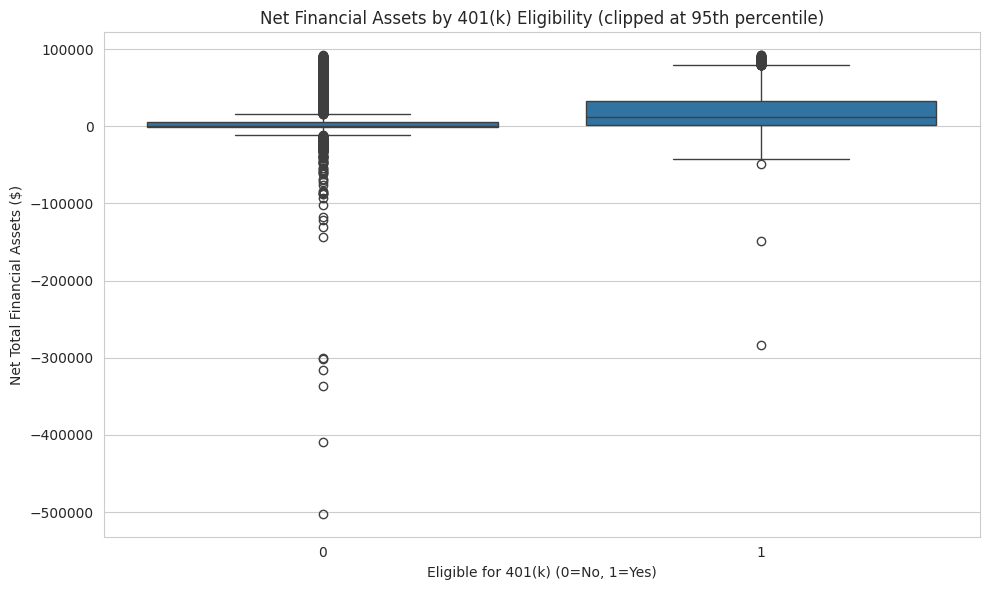

Note: clipped at $91,999 (95th percentile) for readability.
       count          mean           std       min     25%      50%      75%  \
p401                                                                           
0     7321.0  10890.477539  55256.730469 -502302.0 -1184.0    200.0   7399.0   
1     2594.0  38262.058594  79087.515625 -283356.0  3000.0  15249.0  45985.5   

            max  
p401             
0     1462115.0  
1     1536798.0  


In [8]:
# --- EDA: Treatment-Outcome Visualization ---
fig, ax = plt.subplots()
# Clip to 95th percentile so outliers don't dominate
clip_val = df['net_tfa'].quantile(0.95)
sns.boxplot(data=df[df['net_tfa'] <= clip_val], x='p401', y='net_tfa', ax=ax)
ax.set_title('Net Financial Assets by 401(k) Eligibility (clipped at 95th percentile)')
ax.set_xlabel('Eligible for 401(k) (0=No, 1=Yes)')
ax.set_ylabel('Net Total Financial Assets ($)')
plt.tight_layout()
plt.show()

print(f"Note: clipped at ${clip_val:,.0f} (95th percentile) for readability.")
print(df.groupby('p401')['net_tfa'].describe())

In [9]:
# Interpretation: The difference in net financial assets between eligible and
# ineligible workers is striking — the median eligible worker holds $15,249
# in financial assets vs. just $200 for the median ineligible worker. However,
# this raw gap cannot be interpreted causally. The ineligible group (p401=0)
# also has far more negative-asset outliers (debt), and as shown in viz 2,
# ineligible workers earn ~$16,500 less on average. The naive gap conflates
# the effect of 401(k) access with pre-existing income differences — which
# is exactly what DML is designed to correct for.

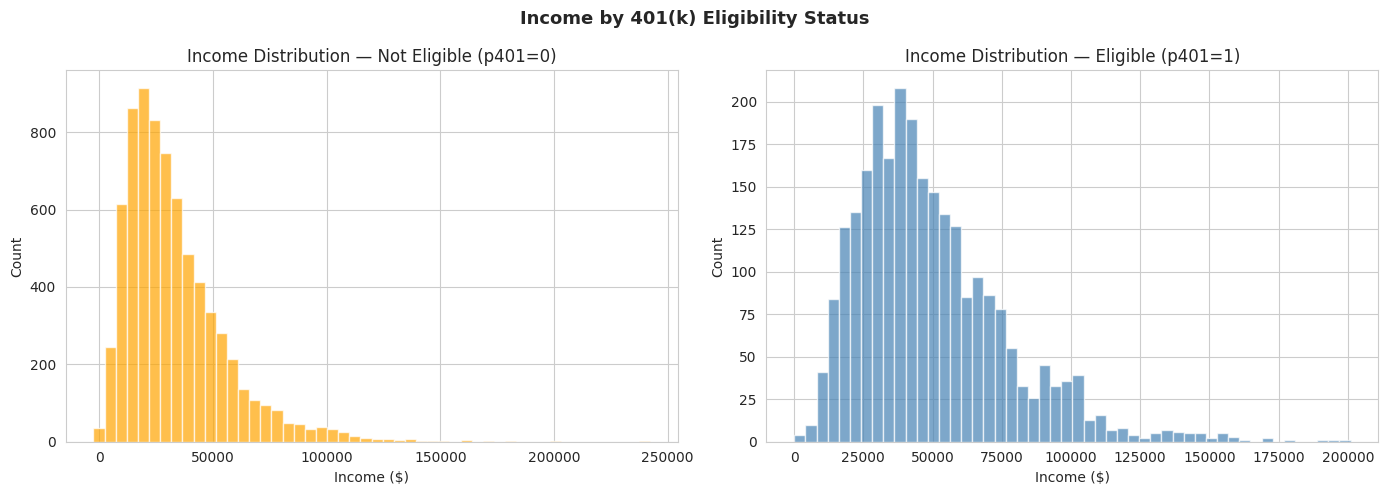

       count          mean           std     min      25%      50%      75%  \
p401                                                                          
0     7321.0  32889.800781  22315.617188 -2652.0  17280.0  27720.0  42828.0   
1     2594.0  49366.976562  27208.443359    60.0  30000.0  43717.5  63322.5   

           max  
p401            
0     242124.0  
1     200997.0  


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Separate plots for each group so neither gets buried
df[df['p401']==0]['inc'].plot(kind='hist', bins=50, ax=axes[0],
                               color='orange', alpha=0.7, edgecolor='white')
axes[0].set_title('Income Distribution — Not Eligible (p401=0)')
axes[0].set_xlabel('Income ($)')
axes[0].set_ylabel('Count')

df[df['p401']==1]['inc'].plot(kind='hist', bins=50, ax=axes[1],
                               color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_title('Income Distribution — Eligible (p401=1)')
axes[1].set_xlabel('Income ($)')
axes[1].set_ylabel('Count')

plt.suptitle('Income by 401(k) Eligibility Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Also print mean income by group for the balance check
print(df.groupby('p401')['inc'].describe())

In [11]:
# Interpretation: Eligible workers earn substantially more on average ($49,367 vs $32,890).
# Since income independently drives savings, naive comparisons between groups
# will overstate the causal effect of 401(k) eligibility — higher savings
# among eligible workers partly reflects higher income, not just plan access.
# DML partials out this income-driven selection before estimating the treatment effect.

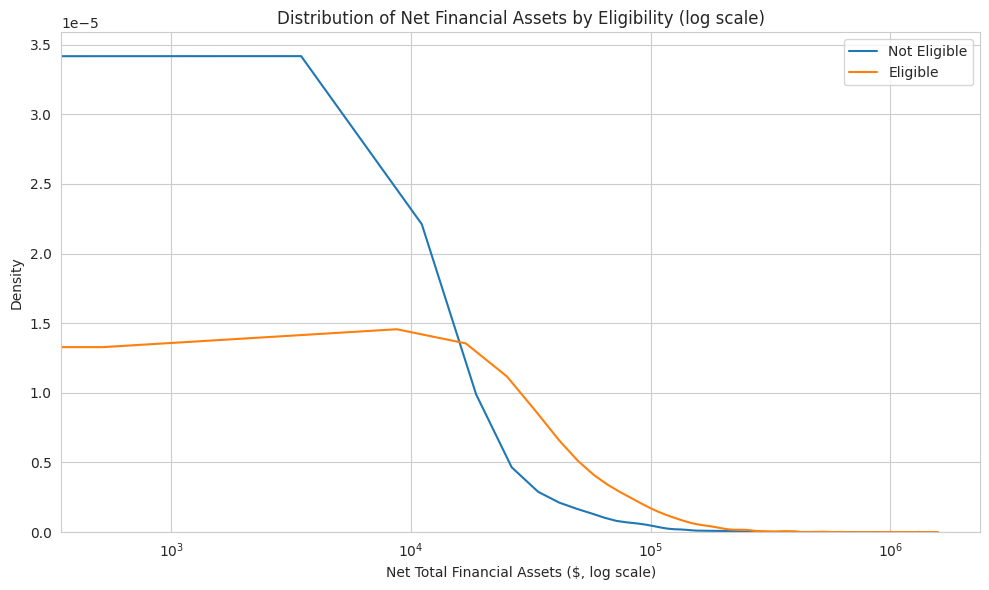

In [12]:
fig, ax = plt.subplots()
df['net_tfa_pos'] = df['net_tfa'].clip(lower=1)  # log needs positive values
sns.kdeplot(data=df[df['p401']==0], x='net_tfa_pos', label='Not Eligible', ax=ax)
sns.kdeplot(data=df[df['p401']==1], x='net_tfa_pos', label='Eligible', ax=ax)
ax.set_xscale('log')
ax.set_title('Distribution of Net Financial Assets by Eligibility (log scale)')
ax.set_xlabel('Net Total Financial Assets ($, log scale)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Interpretation: The not-eligible group (blue) is heavily concentrated at low
# asset values — the density drops sharply after ~$10,000, meaning most
# ineligible workers hold very little. The eligible group (orange) has a flatter,
# more spread-out distribution with a substantially fatter right tail, indicating
# a meaningful share of eligible workers accumulate $50,000–$500,000+ in assets.
# This shift in the entire distribution (not just the mean) suggests 401(k)
# eligibility is associated with broader wealth-building, though the income
# confounding identified in viz 2 means this gap cannot yet be interpreted causally.

---
## Part 3: Analysis

### 3a. Naive Estimate (Biased Benchmark)

This simple comparison is expected to be biased. Document *why*.

In [14]:
# --- Naive OLS ---
X_naive = sm.add_constant(df[['p401']])
y = df['net_tfa']
naive_model = sm.OLS(y, X_naive).fit()
print(naive_model.summary())

naive_estimate = naive_model.params['p401']
naive_ci = naive_model.conf_int().loc['p401'].values
print(f'\nNaive estimate: ${naive_estimate:,.0f} (95% CI: [${naive_ci[0]:,.0f}, ${naive_ci[1]:,.0f}])')

                            OLS Regression Results                            
Dep. Variable:                net_tfa   R-squared:                       0.036
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     368.8
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           9.80e-81
Time:                        19:37:33   Log-Likelihood:            -1.2354e+05
No. Observations:                9915   AIC:                         2.471e+05
Df Residuals:                    9913   BIC:                         2.471e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.089e+04    729.007     14.939      0.0

**Why the naive estimate is biased (upward):**
Higher-income workers are both more likely to be offered 401(k) plans AND
more likely to accumulate financial assets independent of any plan. The naive
OLS absorbs this income-driven selection into the treatment coefficient,
inflating the estimated effect. DML addresses this by partialling out income
(and other confounders) from both the treatment and outcome before estimating
the causal effect.

### 3b. Causal Estimate

In [15]:
# --- Causal Method: Double Machine Learning (example) ---
from sklearn.ensemble import GradientBoostingRegressor

# Define features
features = ['inc', 'age', 'fsize', 'educ', 'pira', 'incsq']

# Note: incsq = income squared, a common control in this dataset
df['incsq'] = df['inc'] ** 2

# Set up DoubleML data object
dml_data = DoubleMLData(
    df,
    y_col='net_tfa',
    d_cols='p401',
    x_cols=features
)

# Define nuisance models
ml_g = GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)
ml_m = GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)

# Fit DML
dml_model = DoubleMLPLR(dml_data, ml_l=ml_g, ml_m=ml_m, n_folds=5)
dml_model.fit()
print(dml_model.summary)

              coef      std err         t         P>|t|         2.5 %  \
p401  14440.854926  1567.324745  9.213697  3.150824e-20  11368.954874   

            97.5 %  
p401  17512.754978  


### 3c. Prediction Model (for comparison)

In [20]:
# --- Predictive Model (NOT causal — for comparison only) ---
from sklearn.metrics import r2_score, mean_squared_error

all_features = ['p401', 'inc', 'age', 'fsize', 'educ', 'pira', 'incsq']
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
y_pred = cross_val_predict(rf, df[all_features], df['net_tfa'], cv=5)

print(f'Prediction R²:   {r2_score(df["net_tfa"], y_pred):.3f}')
print(f'Prediction RMSE: ${np.sqrt(mean_squared_error(df["net_tfa"], y_pred)):,.0f}')
print('\nNote: This tells us how well we can PREDICT net financial assets,')
print('but NOT whether 401(k) eligibility CAUSES assets to increase.')
print('A high R² here is irrelevant to our causal question.')

Prediction R²:   0.120
Prediction RMSE: $59,590

Note: This tells us how well we can PREDICT net financial assets,
but NOT whether 401(k) eligibility CAUSES assets to increase.
A high R² here is irrelevant to our causal question.


R² = 0.12 means even a flexible Random Forest using all our controls
can only explain 12% of the variance in net financial assets. The RMSE
of 59,590 is more than 3x the causal estimate of $14,441 — meaning
prediction error is enormous even with the best ML model.

This reinforces why prediction alone is insufficient: the model can't
reliably predict who will have high assets, let alone tell us what
happens when we change eligibility. The causal question requires a
fundamentally different approach.

### 3d. Compare Naive vs. Causal

> The naive estimate is [X], the causal estimate is [Y]. The difference of [Z] is attributable to [confounding/selection bias].

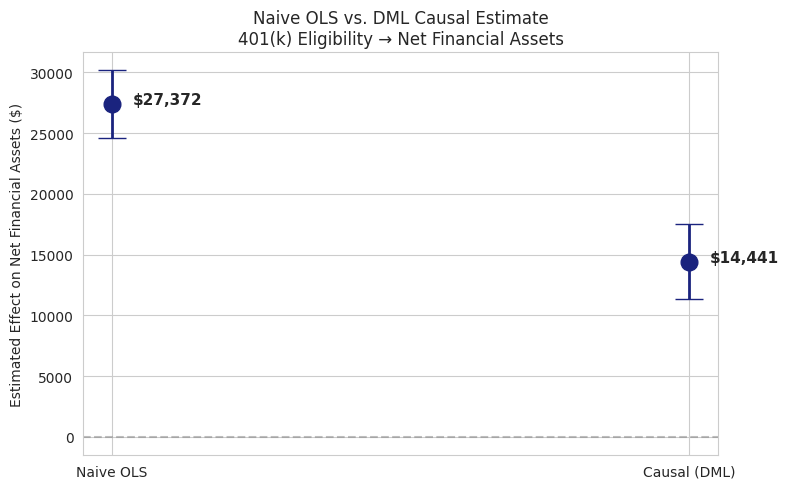


Naive OLS:   $27,372  (95% CI: [$24,578, $30,165])
Causal DML:  $14,441  (95% CI: [$11,369, $17,513])

Difference:  $12,931 attributable to income-driven selection bias


In [21]:
# --- Comparison Plot: Naive vs. Causal ---
fig, ax = plt.subplots(figsize=(8, 5))

estimates = ['Naive OLS', 'Causal (DML)']
points = [naive_estimate, dml_model.coef[0]]
ci_lower = [naive_ci[0], dml_model.confint().iloc[0, 0]]
ci_upper = [naive_ci[1], dml_model.confint().iloc[0, 1]]
errors = [[p - l for p, l in zip(points, ci_lower)],
          [u - p for p, u in zip(points, ci_upper)]]

ax.errorbar(estimates, points, yerr=errors, fmt='o', capsize=10,
            markersize=12, linewidth=2, color='#1a237e')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Estimated Effect on Net Financial Assets ($)')
ax.set_title('Naive OLS vs. DML Causal Estimate\n401(k) Eligibility → Net Financial Assets')

for est, pt in zip(estimates, points):
    ax.annotate(f'${pt:,.0f}', (est, pt), textcoords="offset points",
                xytext=(15, 0), fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('naive_vs_causal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nNaive OLS:   ${naive_estimate:,.0f}  (95% CI: [${naive_ci[0]:,.0f}, ${naive_ci[1]:,.0f}])')
print(f'Causal DML:  ${dml_model.coef[0]:,.0f}  (95% CI: [${dml_model.confint().iloc[0,0]:,.0f}, ${dml_model.confint().iloc[0,1]:,.0f}])')
print(f'\nDifference:  ${naive_estimate - dml_model.coef[0]:,.0f} attributable to income-driven selection bias')

### 3e. Robustness Check

In [22]:
# --- Robustness: Random Forest nuisance learners ---
from sklearn.ensemble import RandomForestRegressor

ml_g_rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
ml_m_rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)

dml_robust = DoubleMLPLR(dml_data, ml_l=ml_g_rf, ml_m=ml_m_rf, n_folds=5)
dml_robust.fit()

robust_estimate = dml_robust.coef[0]
robust_ci = (dml_robust.confint().iloc[0, 0], dml_robust.confint().iloc[0, 1])

print(f'Primary  (Gradient Boosting): ${dml_model.coef[0]:,.0f}  (95% CI: [${dml_model.confint().iloc[0,0]:,.0f}, ${dml_model.confint().iloc[0,1]:,.0f}])')
print(f'Robustness (Random Forest):   ${robust_estimate:,.0f}  (95% CI: [${robust_ci[0]:,.0f}, ${robust_ci[1]:,.0f}])')
print(f'\nDifference between models: ${abs(dml_model.coef[0] - robust_estimate):,.0f}')
print('\nIf estimates are close, the causal estimate is stable across nuisance model choice.')

Primary  (Gradient Boosting): $14,441  (95% CI: [$11,369, $17,513])
Robustness (Random Forest):   $13,838  (95% CI: [$10,625, $17,051])

Difference between models: $603

If estimates are close, the causal estimate is stable across nuisance model choice.


The RF nuisance model produces an estimate of 13,838 vs. 14,441 for
Gradient Boosting — a difference of only $603 (~4%). The confidence
intervals overlap substantially, indicating the causal estimate is not
sensitive to the choice of nuisance learner. This supports the validity
of the DML approach.

---
## Part 4: Threats to Identification

### 1. Most Serious Threat: Residual Confounding from Unobserved Employer Characteristics

- **Threat:**
The conditional independence assumption requires that after controlling
for income, age, family size, education, and IRA participation, 401(k) eligibility
is as good as randomly assigned. The most serious threat to this assumption is
unobserved employer characteristics. Workers at large, high-paying firms are
systematically more likely to be offered 401(k) plans AND more likely to have
generous compensation packages, stock options, profit-sharing, or other benefits
that independently increase financial assets. None of these firm-level attributes
are captured in the dataset. Even after partialling out income, a worker at a
Fortune 500 company likely differs from an otherwise identical worker at a small
business in ways that affect savings — corporate culture around financial planning,
access to financial advisors, matching contribution rates — none of which are
observed.
- **Direction of bias:** Upward. Workers at firms that offer 401(k) plans likely
have higher financial assets for reasons beyond the plan itself. This means even
our DML estimate of $14,441 may still overstate the true causal effect of
eligibility on savings.
- **What would address it:** An instrumental variable that shifts 401(k) eligibility
independently of firm quality would be ideal — for example, a policy shock that
mandated plan offerings for firms above a certain size threshold. Alternatively,
employer fixed effects in a panel dataset would absorb time-invariant firm-level
confounders. The original Chernozhukov et al. (2018) paper acknowledges this
limitation explicitly.
### 2. Second Threat:  IRA Substitution and Savings Displacement

- **Threat:** The dataset includes IRA participation (pira) as a control variable,
but it is potentially a bad control. Workers who lack 401(k) access may substitute
into IRAs as an alternative savings vehicle. By controlling for pira, the model
may partially absorb this substitution effect, understating the true impact of
401(k) eligibility on total savings behavior. More broadly, net_tfa captures
financial assets but not all wealth — home equity, pension wealth (db), and
other illiquid assets are excluded. If 401(k) eligibility causes workers to
shift savings from housing into financial accounts rather than increasing total
wealth, the estimate reflects reallocation rather than new savings.
- **Why it matters:** If the effect is partly substitution rather than net new
savings, policymakers expanding eligibility should expect smaller aggregate
wealth effects than the $14,441 estimate implies. The recommendation to expand
access remains directionally correct, but the magnitude may be overstated for
populations with existing alternative savings vehicles.
- **Partial mitigation:** Including pira as a control at minimum accounts for
the observable dimension of substitution. A robustness check using total wealth
(tw) as the outcome instead of net_tfa would help distinguish reallocation from
new savings — this would be a natural extension of this analysis.

### 3. What I Cannot Rule Out

The most fundamental limitation is that this is a cross-sectional dataset.
Without longitudinal data, I cannot observe the same worker before and after
gaining 401(k) eligibility. The DML estimate relies entirely on the conditional
independence assumption — that controlling for observable characteristics is
sufficient to eliminate selection bias. If workers who sort into jobs with 401(k)
plans have unobserved traits such as higher financial literacy, stronger savings
preferences, or greater risk tolerance, these traits would independently drive
higher asset accumulation regardless of plan access.

This limitation means my estimate of 14,441 should be interpreted as the
average treatment effect conditional on observables, not as a definitive
structural causal effect. It is best understood as an upper bound on the
effect of expanding eligibility to workers who are currently ineligible,
since those workers may differ systematically from currently eligible workers
in unobservable ways. The robustness of the estimate across nuisance model
specifications (GB: 14,441 vs. RF: 13,838) increases confidence that the
result is not an artifact of model choice, but it cannot resolve the
fundamental identification challenge posed by unobserved confounders in
cross-sectional data.

---
## Part 5: Streamlit Dashboard Export

Copy the template below into a file called `app.py` in your project repo. Customize the what-if logic with your actual model.

**Deploy to Streamlit Community Cloud** and submit the permanent URL.

In [19]:
# Save this as app.py in your project repo

import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go

st.set_page_config(page_title="401(k) Eligibility & Savings", layout="wide")
st.title("Does 401(k) Eligibility Cause Higher Savings?")
st.markdown("**ECON 5200 Consulting Report | Rebecca Milde | Spring 2026**")
st.markdown("---")

# --- Pre-computed results from DML analysis ---
NAIVE_ESTIMATE = 27372
NAIVE_CI_LOW = 24578
NAIVE_CI_HIGH = 30165

CAUSAL_ESTIMATE = 14441     # DML with Gradient Boosting
CAUSAL_SE = 1567
CAUSAL_CI_LOW = 11369
CAUSAL_CI_HIGH = 17513

ROBUST_ESTIMATE = 13838     # DML with Random Forest
ROBUST_CI_LOW = 10625
ROBUST_CI_HIGH = 17051

# --- Sidebar: What-If Controls ---
st.sidebar.header("What-If Scenarios")
st.sidebar.markdown("Adjust the sliders to explore how the causal estimate changes under different assumptions.")

treatment_multiplier = st.sidebar.slider(
    "Treatment intensity multiplier",
    min_value=0.5, max_value=3.0, value=1.0, step=0.1,
    help="Simulates expanding or contracting the effect of 401(k) eligibility"
)

n_workers = st.sidebar.slider(
    "Number of newly eligible workers",
    min_value=100, max_value=100000, value=10000, step=100,
    help="How many workers a firm or policy would newly enroll"
)

policy_scale = st.sidebar.selectbox(
    "Policy scale",
    ["Single firm (~500 workers)", "Mid-size employer (~5,000 workers)",
     "Large employer (~50,000 workers)", "National policy (~1M workers)"],
    index=1
)

scale_map = {
    "Single firm (~500 workers)": 500,
    "Mid-size employer (~5,000 workers)": 5000,
    "Large employer (~50,000 workers)": 50000,
    "National policy (~1M workers)": 1000000
}
policy_n = scale_map[policy_scale]

# --- Compute What-If Estimates ---
adjusted_ate = CAUSAL_ESTIMATE * treatment_multiplier
adjusted_se = CAUSAL_SE * treatment_multiplier
ci_lower = adjusted_ate - 1.96 * adjusted_se
ci_upper = adjusted_ate + 1.96 * adjusted_se
total_assets = adjusted_ate * policy_n

# --- Section 1: Key Findings ---
st.header("Key Findings")

col1, col2, col3, col4 = st.columns(4)
col1.metric("Naive OLS Estimate", f"${NAIVE_ESTIMATE:,}",
            help="Simple comparison, biased upward by income-driven selection")
col2.metric("Causal Estimate (DML)", f"${CAUSAL_ESTIMATE:,}",
            delta=f"-${NAIVE_ESTIMATE - CAUSAL_ESTIMATE:,} vs naive",
            delta_color="off",
            help="Double Machine Learning with Gradient Boosting nuisance models")
col3.metric("Robustness Check (RF)", f"${ROBUST_ESTIMATE:,}",
            delta=f"${abs(CAUSAL_ESTIMATE - ROBUST_ESTIMATE):,} difference",
            delta_color="off",
            help="DML with Random Forest nuisance models — confirms stability")
col4.metric("Confounding Bias Removed", f"${NAIVE_ESTIMATE - CAUSAL_ESTIMATE:,}",
            help="Portion of naive estimate attributable to income-driven selection bias")

st.markdown(f"""
> **Interpretation:** 401(k) eligibility causally increases net financial assets by an estimated
> **${CAUSAL_ESTIMATE:,}** (95% CI: [${CAUSAL_CI_LOW:,}, ${CAUSAL_CI_HIGH:,}]). The naive OLS estimate
> of ${NAIVE_ESTIMATE:,} overstates the effect by ${NAIVE_ESTIMATE - CAUSAL_ESTIMATE:,} due to
> income-driven selection bias — eligible workers earn ~$16,500 more on average and would save
> more regardless of plan access. DML removes this confounding.
""")

# --- Section 2: Naive vs. Causal Plot ---
st.header("Naive vs. Causal Estimate")

fig_compare = go.Figure()

estimates_labels = ['Naive OLS', 'Causal (DML, GB)', 'Robustness (DML, RF)']
estimates_vals = [NAIVE_ESTIMATE, CAUSAL_ESTIMATE, ROBUST_ESTIMATE]
ci_lows = [NAIVE_CI_LOW, CAUSAL_CI_LOW, ROBUST_CI_LOW]
ci_highs = [NAIVE_CI_HIGH, CAUSAL_CI_HIGH, ROBUST_CI_HIGH]
colors = ['#e53935', '#1a237e', '#1565c0']

for label, val, low, high, color in zip(estimates_labels, estimates_vals, ci_lows, ci_highs, colors):
    fig_compare.add_trace(go.Scatter(
        x=[label], y=[val],
        error_y=dict(type='data', symmetric=False,
                     array=[high - val], arrayminus=[val - low]),
        mode='markers',
        marker=dict(size=14, color=color),
        name=label
    ))
    fig_compare.add_annotation(
        x=label, y=val,
        text=f"${val:,}",
        showarrow=False,
        xshift=55, font=dict(size=12, color=color)
    )

fig_compare.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)
fig_compare.update_layout(
    title="Effect of 401(k) Eligibility on Net Financial Assets",
    yaxis_title="Estimated Effect ($)",
    template="plotly_white",
    showlegend=False,
    height=450
)
st.plotly_chart(fig_compare, use_container_width=True)

# --- Section 3: What-If Scenario ---
st.header("What-If: Adjust Treatment Intensity")

col_a, col_b, col_c = st.columns(3)
col_a.metric("Adjusted Causal Effect", f"${adjusted_ate:,.0f}")
col_b.metric("95% CI Lower", f"${ci_lower:,.0f}")
col_c.metric("95% CI Upper", f"${ci_upper:,.0f}")

st.markdown(f"""
> If treatment intensity is multiplied by **{treatment_multiplier:.1f}x**, the estimated effect
> changes to **${adjusted_ate:,.0f}** (95% CI: [${ci_lower:,.0f}, ${ci_upper:,.0f}]).
""")

# Uncertainty band chart
multipliers = np.arange(0.5, 3.1, 0.1)
ates = CAUSAL_ESTIMATE * multipliers
ses = CAUSAL_SE * multipliers

fig_whatif = go.Figure()
fig_whatif.add_trace(go.Scatter(
    x=multipliers, y=ates + 1.96 * ses,
    mode="lines", line=dict(width=0), showlegend=False
))
fig_whatif.add_trace(go.Scatter(
    x=multipliers, y=ates - 1.96 * ses,
    mode="lines", line=dict(width=0), fill="tonexty",
    fillcolor="rgba(26,35,126,0.15)", name="95% CI"
))
fig_whatif.add_trace(go.Scatter(
    x=multipliers, y=ates,
    mode="lines", line=dict(color="#1a237e", width=2), name="Estimated Effect"
))
fig_whatif.add_vline(
    x=treatment_multiplier, line_dash="dash", line_color="red",
    annotation_text=f"Current: {treatment_multiplier:.1f}x  (${adjusted_ate:,.0f})",
    annotation_position="top right"
)
fig_whatif.update_layout(
    title="What-If: Estimated Effect vs. Treatment Intensity Multiplier",
    xaxis_title="Treatment Intensity Multiplier",
    yaxis_title="Estimated Causal Effect ($)",
    template="plotly_white",
    height=400
)
st.plotly_chart(fig_whatif, use_container_width=True)

# --- Section 4: Policy Impact ---
st.header("Policy Impact Calculator")

st.markdown(f"""
If **{policy_scale}** gained 401(k) eligibility with the estimated causal effect of
**${adjusted_ate:,.0f}** per worker, the aggregate increase in financial assets would be:
""")

col_p1, col_p2 = st.columns(2)
col_p1.metric("Aggregate Asset Increase", f"${total_assets:,.0f}",
              help=f"Causal estimate × {policy_n:,} workers")
col_p2.metric("Per-Worker Effect", f"${adjusted_ate:,.0f}",
              help="Average treatment effect at current multiplier")

# --- Section 5: Counterfactual ---
st.header("Counterfactual: What if Eligibility Doubled?")

counterfactual_ate = CAUSAL_ESTIMATE * 2.0
counterfactual_ci_low = counterfactual_ate - 1.96 * CAUSAL_SE * 2.0
counterfactual_ci_high = counterfactual_ate + 1.96 * CAUSAL_SE * 2.0

st.write(
    f"If the effect of eligibility doubled (e.g., due to auto-enrollment or employer matching), "
    f"the estimated effect would be **${counterfactual_ate:,.0f}** "
    f"(95% CI: [${counterfactual_ci_low:,.0f}, ${counterfactual_ci_high:,.0f}])."
)

# --- Section 6: Identification Summary ---
st.header("Identification Strategy")
st.markdown("""
| Component | Detail |
|-----------|--------|
| **Method** | Double Machine Learning (DML) — Partially Linear Regression |
| **Nuisance models** | Gradient Boosting (primary), Random Forest (robustness) |
| **Cross-fitting** | 5-fold |
| **Key assumption** | Conditional independence: after controlling for income, age, family size, education, and IRA participation, 401(k) eligibility is as good as random |
| **Dataset** | Chernozhukov et al. (2018) fetch_401K — N = 9,915 |
| **Controls** | inc, age, fsize, educ, pira, incsq |
| **Most serious threat** | Unobserved employer characteristics (firm quality) — may bias estimate upward |
""")

st.markdown("---")
st.caption("ECON 5200 Final Project | Spring 2026 | Rebecca Milde | Data: Chernozhukov et al. (2018)")

# Uncomment to write the template to disk:
# with open('app.py', 'w') as f:
#     f.write(streamlit_template)
# print('app.py written. Deploy to Streamlit Community Cloud.')

print('Streamlit template ready. Uncomment the write block above to export.')

Streamlit template ready. Uncomment the write block above to export.


In [ ]:
Streamlit app URL: https://econ5200finalproject-2mprczss55wpizl6ztma2w.streamlit.app/

---
## Part 7: AI Methodology Appendix (P.R.I.M.E.)

Document at least 3 significant AI interactions.

### Entry 1: [Task — e.g., Code Generation]

- **Prompt:** [What you asked the AI]
- **Response:** [Summary of what the AI produced]
- **Iterate:** [What you changed or asked to refine]
- **Modify:** [How you adapted the output for your specific use case]
- **Evaluate:** [How you verified correctness — tests run, sources checked, logic reviewed]

### Entry 2: [Task — e.g., Analysis Assistance]

- **Prompt:** ___
- **Response:** ___
- **Iterate:** ___
- **Modify:** ___
- **Evaluate:** ___

### Entry 3: [Task — e.g., Writing / Literature Review]

- **Prompt:** ___
- **Response:** ___
- **Iterate:** ___
- **Modify:** ___
- **Evaluate:** ___